# ⚡ EnerSense AI
## Intelligent Building Energy Optimization

### Yuva Yodha Energy Tech Hackathon 2026

**Objective:**  
Develop an AI-powered system that analyzes building energy consumption,
forecasts future demand, detects abnormal energy usage, and provides
actionable energy-saving recommendations.

### Core Pipeline
**Predict → Detect → Recommend → Save**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
import os

print("Current working directory:")
print(os.getcwd())

print("\nFiles/folders here:")
print(os.listdir())

import os

for root, dirs, files in os.walk(os.getcwd()):
    if "electricity_cleaned.csv" in files:
        print("FOUND:")
        print(os.path.join(root, "electricity_cleaned.csv"))

Current working directory:
c:\Users\Admin\OneDrive\Desktop\EnerSense_AI\NOTEBOOK

Files/folders here:
['EnerSense_AI.html', 'EnerSense_AI.ipynb']


In [3]:
import os

print(os.path.exists("../data"))
print(os.listdir("../data"))

import pandas as pd

electricity = pd.read_csv("../data/electricity_cleaned.csv")
metadata = pd.read_csv("../data/metadata.csv")
weather = pd.read_csv("../data/weather.csv")

print("Electricity:", electricity.shape)
print("Metadata:", metadata.shape)
print("Weather:", weather.shape)

import os

print(os.path.exists("../data"))
print(os.listdir(".."))

True
['electricity_cleaned.csv', 'metadata.csv', 'processed', 'weather.csv']
Electricity: (17544, 1579)
Metadata: (1636, 32)
Weather: (331166, 10)
True
['DASHBOARD', 'DATA', 'IMAGES', 'MODELS', 'NOTEBOOK', 'REQUIREMENT.txt', 'SRC']


Inspect Electricity


In [4]:
print("Electricity shape:", electricity.shape)

print("\nFirst 5 rows:")
display(electricity.head())

print("\nColumn names:")
print(electricity.columns.tolist()[:30])

print(electricity.dtypes.head(20))

Electricity shape: (17544, 1579)

First 5 rows:


,timestamp,Panther_parking_Lorriane,Panther_lodging_Cora,Panther_office_Hannah,Panther_lodging_Hattie,Panther_education_Teofila,Panther_education_Jerome,Panther_retail_Felix,Panther_parking_Asia,Panther_education_Misty,...,Cockatoo_public_Caleb,Cockatoo_education_Tyler,Cockatoo_public_Shad,Mouse_health_Buddy,Mouse_health_Modesto,Mouse_lodging_Vicente,Mouse_health_Justin,Mouse_health_Ileana,Mouse_health_Estela,Mouse_science_Micheal
0,2016-01-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,123.200,727.575,69.200,8.8224,370.0870,10.0,282.9965,26.0,135.0,168.2243
1,2016-01-01 01:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,126.475,731.200,66.275,17.6449,737.8260,30.0,574.9265,51.0,265.0,336.4486
2,2016-01-01 02:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,127.825,724.675,64.675,17.6449,729.9255,30.0,570.2780,50.0,272.0,336.4486
3,2016-01-01 03:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,130.475,737.375,65.875,17.6449,722.2620,20.0,561.1470,52.0,276.0,336.4486
4,2016-01-01 04:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,129.675,721.150,66.275,17.6449,719.1665,30.0,564.3695,50.0,280.0,336.4486



Column names:
['timestamp', 'Panther_parking_Lorriane', 'Panther_lodging_Cora', 'Panther_office_Hannah', 'Panther_lodging_Hattie', 'Panther_education_Teofila', 'Panther_education_Jerome', 'Panther_retail_Felix', 'Panther_parking_Asia', 'Panther_education_Misty', 'Panther_retail_Gilbert', 'Panther_office_Catherine', 'Panther_education_Tina', 'Panther_education_Janis', 'Panther_office_Patti', 'Panther_retail_Romeo', 'Panther_office_Lauretta', 'Panther_parking_Alaina', 'Panther_office_Valarie', 'Panther_lodging_Blaine', 'Panther_office_Karla', 'Panther_education_Quintin', 'Panther_assembly_Pamella', 'Panther_office_Graham', 'Panther_office_Larry', 'Panther_lodging_Jorge', 'Panther_education_Violet', 'Panther_lodging_Edison', 'Panther_office_Ruthie', 'Panther_lodging_Awilda']
timestamp                        str
Panther_parking_Lorriane     float64
Panther_lodging_Cora         float64
Panther_office_Hannah        float64
Panther_lodging_Hattie       float64
Panther_education_Teofila    fl

In [5]:
# Convert timestamp to datetime
electricity["timestamp"] = pd.to_datetime(electricity["timestamp"])

# Calculate missing percentage for every meter
missing_percentage = electricity.drop(columns="timestamp").isna().mean() * 100

# Show the 20 meters with the least missing data
best_meters = missing_percentage.sort_values().head(20)

print("Top 20 meters with the least missing data:")
display(best_meters)

# Show basic information about the best meter
best_meter = best_meters.index[0]

print("Selected meter:", best_meter)
print("Missing values:", missing_percentage[best_meter], "%")
print("Non-null readings:", electricity[best_meter].notna().sum())

print("Selected meter:", best_meter)

display(
    electricity[["timestamp", best_meter]]
    .head(10)
)
display(
    electricity[["timestamp", best_meter]]
    .describe()
)

Top 20 meters with the least missing data:


Hog_other_Tobias           0.0
Hog_office_Shawna          0.0
Lamb_education_Armando     0.0
Lamb_assembly_Librada      0.0
Lamb_education_Mae         0.0
Hog_office_Merilyn         0.0
Hog_office_Almeda          0.0
Hog_office_Lavon           0.0
Hog_office_Denita          0.0
Hog_education_Rachael      0.0
Lamb_education_Willetta    0.0
Lamb_education_Lucas       0.0
Lamb_industrial_Enrique    0.0
Hog_food_Morgan            0.0
Hog_education_Madge        0.0
Lamb_assembly_Rosa         0.0
Lamb_industrial_Carla      0.0
Lamb_education_Lazaro      0.0
Hog_industrial_Quentin     0.0
Moose_education_Ricardo    0.0
dtype: float64

Selected meter: Hog_other_Tobias
Missing values: 0.0 %
Non-null readings: 17544
Selected meter: Hog_other_Tobias


,timestamp,Hog_other_Tobias
0,2016-01-01 00:00:00,43.321
1,2016-01-01 01:00:00,43.321
2,2016-01-01 02:00:00,43.287
3,2016-01-01 03:00:00,41.966
4,2016-01-01 04:00:00,47.349
5,2016-01-01 05:00:00,60.070
6,2016-01-01 06:00:00,64.833
7,2016-01-01 07:00:00,62.559
8,2016-01-01 08:00:00,64.525
9,2016-01-01 09:00:00,55.837


,timestamp,Hog_other_Tobias
count,17544,17544.000000
mean,2016-12-31 11:30:00,37.500048
min,2016-01-01 00:00:00,8.833000
25%,2016-07-01 17:45:00,26.865000
50%,2016-12-31 11:30:00,36.049500
75%,2017-07-02 05:15:00,46.126000
max,2017-12-31 23:00:00,76.700000
std,NaN,12.499384


Inspect Metadata


In [6]:
print("Metadata shape:", metadata.shape)

display(metadata.head())

print("\nMetadata columns:")
print(metadata.columns.tolist())

Metadata shape: (1636, 32)


,building_id,site_id,building_id_kaggle,site_id_kaggle,primaryspaceusage,sub_primaryspaceusage,sqm,sqft,lat,lng,...,yearbuilt,date_opened,numberoffloors,occupants,energystarscore,eui,site_eui,source_eui,leed_level,rating
0,Panther_lodging_Dean,Panther,NaN,0.0,Lodging/residential,Residence Hall,508.8,5477.0,28.517689,-81.379039,...,1989.0,NaN,NaN,NaN,NaN,271,NaN,NaN,NaN,NaN
1,Panther_lodging_Shelia,Panther,NaN,0.0,Lodging/residential,Residence Hall,929.0,10000.0,28.517689,-81.379039,...,1992.0,NaN,NaN,NaN,NaN,62,NaN,NaN,NaN,NaN
2,Panther_lodging_Ricky,Panther,NaN,0.0,Lodging/residential,Residence Hall,483.1,5200.0,28.517689,-81.379039,...,2016.0,NaN,NaN,NaN,NaN,534,NaN,NaN,NaN,NaN
3,Panther_education_Rosalie,Panther,0.0,0.0,Education,Research,690.5,7432.0,28.517689,-81.379039,...,2008.0,NaN,NaN,NaN,NaN,276,NaN,NaN,NaN,NaN
4,Panther_education_Misty,Panther,1.0,0.0,Education,Research,252.7,2720.0,28.517689,-81.379039,...,2004.0,NaN,NaN,NaN,NaN,375,NaN,NaN,NaN,NaN



Metadata columns:
['building_id', 'site_id', 'building_id_kaggle', 'site_id_kaggle', 'primaryspaceusage', 'sub_primaryspaceusage', 'sqm', 'sqft', 'lat', 'lng', 'timezone', 'electricity', 'hotwater', 'chilledwater', 'steam', 'water', 'irrigation', 'solar', 'gas', 'industry', 'subindustry', 'heatingtype', 'yearbuilt', 'date_opened', 'numberoffloors', 'occupants', 'energystarscore', 'eui', 'site_eui', 'source_eui', 'leed_level', 'rating']


In [7]:
# Make sure timestamp is datetime
electricity["timestamp"] = pd.to_datetime(electricity["timestamp"])

# Calculate missing percentage for each electricity meter
missing_percentage = (
    electricity.drop(columns="timestamp")
    .isna()
    .mean() * 100
)

# Top 20 meters with least missing data
best_meters = missing_percentage.sort_values().head(20)

display(best_meters)
# Select the meter with the least missing data
best_meter = best_meters.index[0]

print("Selected meter:", best_meter)
print("Missing percentage:", round(missing_percentage[best_meter], 2), "%")
print("Available readings:", electricity[best_meter].notna().sum())

building_info = metadata[
    metadata["building_id"] == best_meter
]

display(building_info.T)

Hog_other_Tobias           0.0
Hog_office_Shawna          0.0
Lamb_education_Armando     0.0
Lamb_assembly_Librada      0.0
Lamb_education_Mae         0.0
Hog_office_Merilyn         0.0
Hog_office_Almeda          0.0
Hog_office_Lavon           0.0
Hog_office_Denita          0.0
Hog_education_Rachael      0.0
Lamb_education_Willetta    0.0
Lamb_education_Lucas       0.0
Lamb_industrial_Enrique    0.0
Hog_food_Morgan            0.0
Hog_education_Madge        0.0
Lamb_assembly_Rosa         0.0
Lamb_industrial_Carla      0.0
Lamb_education_Lazaro      0.0
Hog_industrial_Quentin     0.0
Moose_education_Ricardo    0.0
dtype: float64

Selected meter: Hog_other_Tobias
Missing percentage: 0.0 %
Available readings: 17544


,1272
building_id,Hog_other_Tobias
site_id,Hog
building_id_kaggle,1103.0
site_id_kaggle,13.0
primaryspaceusage,Other
sub_primaryspaceusage,Animal Shelter
sqm,2220.7
sqft,23903.0
lat,44.978782
lng,-93.255398


Inspect Weather

In [8]:
print("Weather shape:", weather.shape)

display(weather.head())

print("\nWeather columns:")
print(weather.columns.tolist())

Weather shape: (331166, 10)


,timestamp,site_id,airTemperature,cloudCoverage,dewTemperature,precipDepth1HR,precipDepth6HR,seaLvlPressure,windDirection,windSpeed
0,2016-01-01 00:00:00,Panther,19.4,NaN,19.4,0.0,NaN,NaN,0.0,0.0
1,2016-01-01 01:00:00,Panther,21.1,6.0,21.1,-1.0,NaN,1019.4,0.0,0.0
2,2016-01-01 02:00:00,Panther,21.1,NaN,21.1,0.0,NaN,1018.8,210.0,1.5
3,2016-01-01 03:00:00,Panther,20.6,NaN,20.0,0.0,NaN,1018.1,0.0,0.0
4,2016-01-01 04:00:00,Panther,21.1,NaN,20.6,0.0,NaN,1019.0,290.0,1.5



Weather columns:
['timestamp', 'site_id', 'airTemperature', 'cloudCoverage', 'dewTemperature', 'precipDepth1HR', 'precipDepth6HR', 'seaLvlPressure', 'windDirection', 'windSpeed']


In [9]:
# Make sure timestamp is datetime
electricity["timestamp"] = pd.to_datetime(electricity["timestamp"])

# Calculate missing percentage for every meter
missing_percentage = (
    electricity.drop(columns="timestamp")
    .isna()
    .mean() * 100
)

# Top 20 meters with the least missing data
best_meters = missing_percentage.sort_values().head(20)

display(best_meters)
best_meter = best_meters.index[0]

print("Selected meter:", best_meter)
print("Missing percentage:", round(missing_percentage[best_meter], 2), "%")
print("Available readings:", electricity[best_meter].notna().sum())

building_info = metadata[
    metadata["building_id"] == best_meter
]

display(building_info.T)

Hog_other_Tobias           0.0
Hog_office_Shawna          0.0
Lamb_education_Armando     0.0
Lamb_assembly_Librada      0.0
Lamb_education_Mae         0.0
Hog_office_Merilyn         0.0
Hog_office_Almeda          0.0
Hog_office_Lavon           0.0
Hog_office_Denita          0.0
Hog_education_Rachael      0.0
Lamb_education_Willetta    0.0
Lamb_education_Lucas       0.0
Lamb_industrial_Enrique    0.0
Hog_food_Morgan            0.0
Hog_education_Madge        0.0
Lamb_assembly_Rosa         0.0
Lamb_industrial_Carla      0.0
Lamb_education_Lazaro      0.0
Hog_industrial_Quentin     0.0
Moose_education_Ricardo    0.0
dtype: float64

Selected meter: Hog_other_Tobias
Missing percentage: 0.0 %
Available readings: 17544


,1272
building_id,Hog_other_Tobias
site_id,Hog
building_id_kaggle,1103.0
site_id_kaggle,13.0
primaryspaceusage,Other
sub_primaryspaceusage,Animal Shelter
sqm,2220.7
sqft,23903.0
lat,44.978782
lng,-93.255398


In [10]:
# Find metadata for our selected building
building_info = metadata[
    metadata["building_id"] == "Hog_other_Tobias"
]

display(building_info.T)
# Extract the site associated with our building
site_id = building_info["site_id"].iloc[0]

print("Building:", "Hog_other_Tobias")
print("Site:", site_id)




,1272
building_id,Hog_other_Tobias
site_id,Hog
building_id_kaggle,1103.0
site_id_kaggle,13.0
primaryspaceusage,Other
sub_primaryspaceusage,Animal Shelter
sqm,2220.7
sqft,23903.0
lat,44.978782
lng,-93.255398


Building: Hog_other_Tobias
Site: Hog


In [11]:
#Check for electricity data for the selected building
energy = electricity[["timestamp", "Hog_other_Tobias"]].copy()

energy = energy.rename(
    columns={"Hog_other_Tobias": "energy_consumption"}
)

print(energy.shape)
display(energy.head())
display(energy.describe())

(17544, 2)


,timestamp,energy_consumption
0,2016-01-01 00:00:00,43.321
1,2016-01-01 01:00:00,43.321
2,2016-01-01 02:00:00,43.287
3,2016-01-01 03:00:00,41.966
4,2016-01-01 04:00:00,47.349


,timestamp,energy_consumption
count,17544,17544.000000
mean,2016-12-31 11:30:00,37.500048
min,2016-01-01 00:00:00,8.833000
25%,2016-07-01 17:45:00,26.865000
50%,2016-12-31 11:30:00,36.049500
75%,2017-07-02 05:15:00,46.126000
max,2017-12-31 23:00:00,76.700000
std,NaN,12.499384


In [12]:
#Check for the weather data for our site
weather["timestamp"] = pd.to_datetime(weather["timestamp"])

site_weather = weather[
    weather["site_id"] == site_id
].copy()

print("Site:", site_id)
print("Weather shape:", site_weather.shape)

display(site_weather.head())

Site: Hog
Weather shape: (17542, 10)


,timestamp,site_id,airTemperature,cloudCoverage,dewTemperature,precipDepth1HR,precipDepth6HR,seaLvlPressure,windDirection,windSpeed
261597,2016-01-01 00:00:00,Hog,-7.2,8.0,-10.6,0.0,-1.0,1022.9,280.0,5.7
261598,2016-01-01 01:00:00,Hog,-6.7,NaN,-10.0,-1.0,NaN,1022.5,280.0,4.1
261599,2016-01-01 02:00:00,Hog,-6.7,NaN,-9.4,0.0,NaN,1022.1,260.0,2.6
261600,2016-01-01 03:00:00,Hog,-6.7,NaN,-9.4,-1.0,NaN,1022.0,250.0,3.6
261601,2016-01-01 04:00:00,Hog,-8.3,NaN,-11.7,0.0,NaN,1021.9,270.0,6.7


Create the EnerSense AI dataset

In [13]:
# Prepare electricity data
energy = electricity[["timestamp", "Hog_other_Tobias"]].copy()

energy = energy.rename(
    columns={"Hog_other_Tobias": "energy_consumption"}
)

energy["timestamp"] = pd.to_datetime(energy["timestamp"])


# Prepare weather data
weather["timestamp"] = pd.to_datetime(weather["timestamp"])

site_weather = weather[
    weather["site_id"] == "Hog"
].copy()


# Keep useful weather features
site_weather = site_weather[
    [
        "timestamp",
        "site_id",
        "airTemperature",
        "cloudCoverage",
        "dewTemperature",
        "precipDepth1HR",
        "precipDepth6HR",
        "seaLvlPressure",
        "windDirection",
        "windSpeed"
    ]
]


# Merge
df = pd.merge(
    energy,
    site_weather,
    on="timestamp",
    how="left"
)

print("Final dataset shape:", df.shape)
display(df.head())

Final dataset shape: (17544, 11)


,timestamp,energy_consumption,site_id,airTemperature,cloudCoverage,dewTemperature,precipDepth1HR,precipDepth6HR,seaLvlPressure,windDirection,windSpeed
0,2016-01-01 00:00:00,43.321,Hog,-7.2,8.0,-10.6,0.0,-1.0,1022.9,280.0,5.7
1,2016-01-01 01:00:00,43.321,Hog,-6.7,NaN,-10.0,-1.0,NaN,1022.5,280.0,4.1
2,2016-01-01 02:00:00,43.287,Hog,-6.7,NaN,-9.4,0.0,NaN,1022.1,260.0,2.6
3,2016-01-01 03:00:00,41.966,Hog,-6.7,NaN,-9.4,-1.0,NaN,1022.0,250.0,3.6
4,2016-01-01 04:00:00,47.349,Hog,-8.3,NaN,-11.7,0.0,NaN,1021.9,270.0,6.7


In [14]:
print("Missing values:")
display(df.isnull().sum())

Missing values:


timestamp                 0
energy_consumption        0
site_id                   2
airTemperature            4
cloudCoverage          8640
dewTemperature            4
precipDepth1HR           53
precipDepth6HR        16815
seaLvlPressure          204
windDirection           445
windSpeed                 4
dtype: int64

In [15]:
# Time-based features

df["hour"] = df["timestamp"].dt.hour
df["day"] = df["timestamp"].dt.day
df["day_of_week"] = df["timestamp"].dt.dayofweek
df["month"] = df["timestamp"].dt.month
df["year"] = df["timestamp"].dt.year

# Weekend indicator
df["is_weekend"] = df["day_of_week"].isin([5, 6]).astype(int)

display(df.head())

,timestamp,energy_consumption,site_id,airTemperature,cloudCoverage,dewTemperature,precipDepth1HR,precipDepth6HR,seaLvlPressure,windDirection,windSpeed,hour,day,day_of_week,month,year,is_weekend
0,2016-01-01 00:00:00,43.321,Hog,-7.2,8.0,-10.6,0.0,-1.0,1022.9,280.0,5.7,0,1,4,1,2016,0
1,2016-01-01 01:00:00,43.321,Hog,-6.7,NaN,-10.0,-1.0,NaN,1022.5,280.0,4.1,1,1,4,1,2016,0
2,2016-01-01 02:00:00,43.287,Hog,-6.7,NaN,-9.4,0.0,NaN,1022.1,260.0,2.6,2,1,4,1,2016,0
3,2016-01-01 03:00:00,41.966,Hog,-6.7,NaN,-9.4,-1.0,NaN,1022.0,250.0,3.6,3,1,4,1,2016,0
4,2016-01-01 04:00:00,47.349,Hog,-8.3,NaN,-11.7,0.0,NaN,1021.9,270.0,6.7,4,1,4,1,2016,0


In [16]:
print("Dataset shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

import os

os.makedirs("../data/processed", exist_ok=True)

df.to_csv(
    "../data/processed/enerSense_building_data.csv",
    index=False
)

print("✅ Processed EnerSense dataset saved successfully!")

Dataset shape: (17544, 17)

Columns:
['timestamp', 'energy_consumption', 'site_id', 'airTemperature', 'cloudCoverage', 'dewTemperature', 'precipDepth1HR', 'precipDepth6HR', 'seaLvlPressure', 'windDirection', 'windSpeed', 'hour', 'day', 'day_of_week', 'month', 'year', 'is_weekend']

Data types:
timestamp             datetime64[us]
energy_consumption           float64
site_id                          str
airTemperature               float64
cloudCoverage                float64
dewTemperature               float64
precipDepth1HR               float64
precipDepth6HR               float64
seaLvlPressure               float64
windDirection                float64
windSpeed                    float64
hour                           int32
day                            int32
day_of_week                    int32
month                          int32
year                           int32
is_weekend                     int64
dtype: object
✅ Processed EnerSense dataset saved successfully!


Shape after cleaning: (17544, 15)

Remaining missing values:


timestamp             0
energy_consumption    0
site_id               2
airTemperature        0
dewTemperature        0
precipDepth1HR        0
seaLvlPressure        0
windDirection         0
windSpeed             0
hour                  0
day                   0
day_of_week           0
month                 0
year                  0
is_weekend            0
dtype: int64

ENERGY CONSUMPTION SUMMARY
Mean:   37.50
Median: 36.05
Min:    8.83
Max:    76.70
Std:    12.50


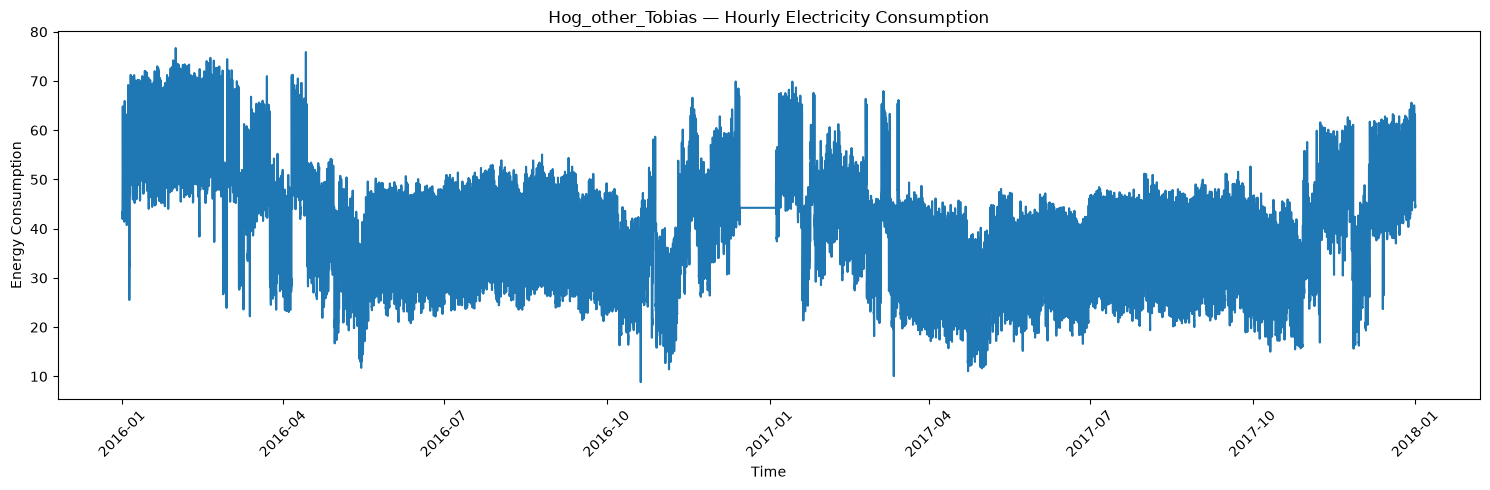

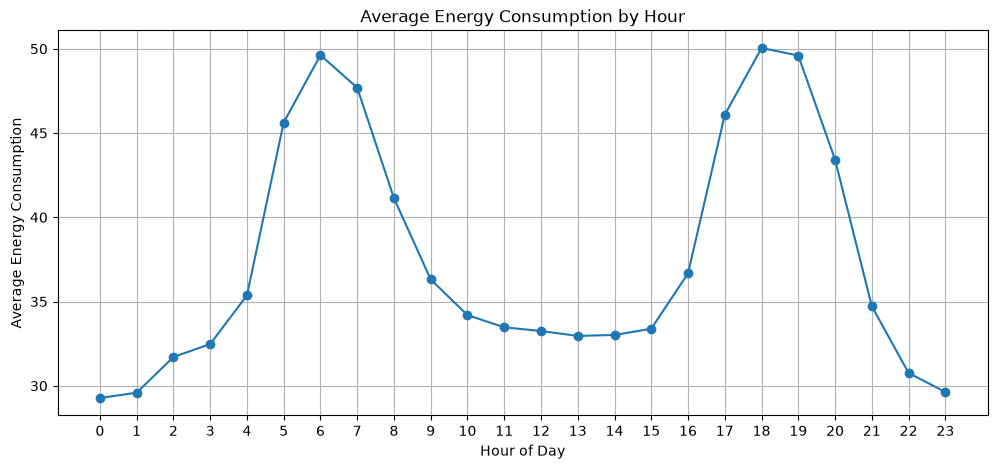

Average energy consumption:
Weekdays : 37.87179078694818
Weekends : 36.57777261904762


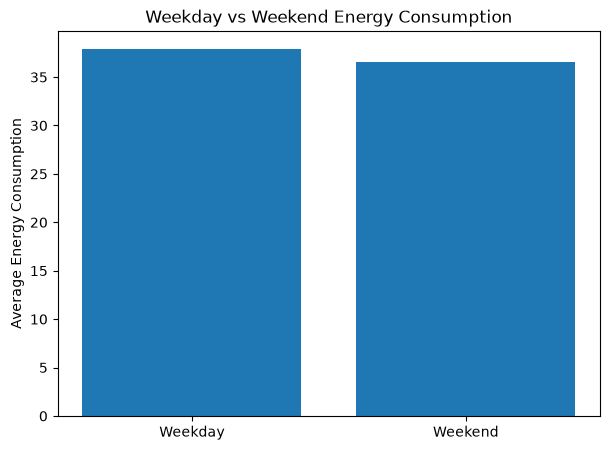

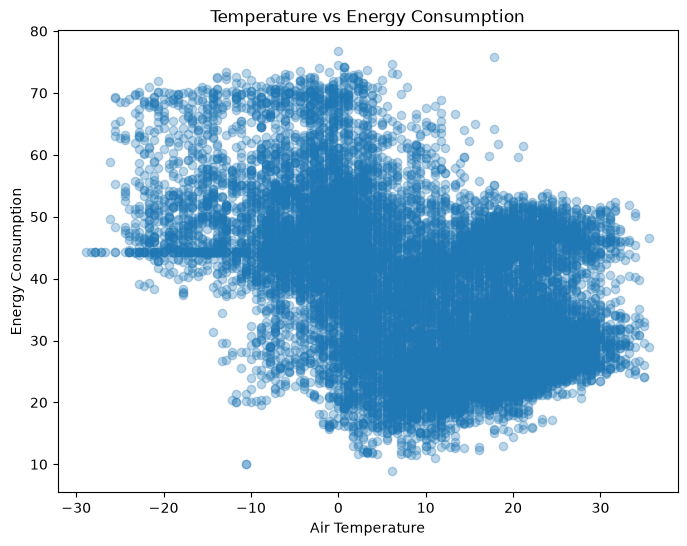

In [17]:
#Clean the modeling dataset
# Make a copy for analysis
analysis_df = df.copy()

# Remove columns with very high missingness
analysis_df = analysis_df.drop(
    columns=["cloudCoverage", "precipDepth6HR"]
)

# Fill small weather gaps using interpolation
weather_features = [
    "airTemperature",
    "dewTemperature",
    "precipDepth1HR",
    "seaLvlPressure",
    "windDirection",
    "windSpeed"
]

analysis_df[weather_features] = (
    analysis_df[weather_features]
    .interpolate(method="linear")
    .ffill()
    .bfill()
)

print("Shape after cleaning:", analysis_df.shape)

print("\nRemaining missing values:")
display(analysis_df.isnull().sum())

#Basic Energy Statistics
print("ENERGY CONSUMPTION SUMMARY")
print("=" * 40)

print(f"Mean:   {analysis_df['energy_consumption'].mean():.2f}")
print(f"Median: {analysis_df['energy_consumption'].median():.2f}")
print(f"Min:    {analysis_df['energy_consumption'].min():.2f}")
print(f"Max:    {analysis_df['energy_consumption'].max():.2f}")
print(f"Std:    {analysis_df['energy_consumption'].std():.2f}")

#Energy Consumption Over Time
plt.figure(figsize=(15, 5))

plt.plot(
    analysis_df["timestamp"],
    analysis_df["energy_consumption"]
)

plt.title("Hog_other_Tobias — Hourly Electricity Consumption")
plt.xlabel("Time")
plt.ylabel("Energy Consumption")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#Average Consumption by Hour
hourly_pattern = (
    analysis_df
    .groupby("hour")["energy_consumption"]
    .mean()
)

plt.figure(figsize=(12, 5))

plt.plot(
    hourly_pattern.index,
    hourly_pattern.values,
    marker="o"
)

plt.title("Average Energy Consumption by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average Energy Consumption")
plt.xticks(range(24))
plt.grid(True)
plt.show()

#Weekday vs Weekend
weekend_pattern = (
    analysis_df
    .groupby("is_weekend")["energy_consumption"]
    .mean()
)

print("Average energy consumption:")
print("Weekdays :", weekend_pattern.get(0))
print("Weekends :", weekend_pattern.get(1))
plt.figure(figsize=(7, 5))

plt.bar(
    ["Weekday", "Weekend"],
    [
        weekend_pattern.get(0),
        weekend_pattern.get(1)
    ]
)

plt.title("Weekday vs Weekend Energy Consumption")
plt.ylabel("Average Energy Consumption")

plt.show()

#Temperature vs Energy
plt.figure(figsize=(8, 6))

plt.scatter(
    analysis_df["airTemperature"],
    analysis_df["energy_consumption"],
    alpha=0.3
)

plt.title("Temperature vs Energy Consumption")
plt.xlabel("Air Temperature")
plt.ylabel("Energy Consumption")

plt.show()

In [18]:
analysis_df["site_id"] = analysis_df["site_id"].fillna("Hog")

print(analysis_df.isnull().sum())

timestamp             0
energy_consumption    0
site_id               0
airTemperature        0
dewTemperature        0
precipDepth1HR        0
seaLvlPressure        0
windDirection         0
windSpeed             0
hour                  0
day                   0
day_of_week           0
month                 0
year                  0
is_weekend            0
dtype: int64


Stronger EDA

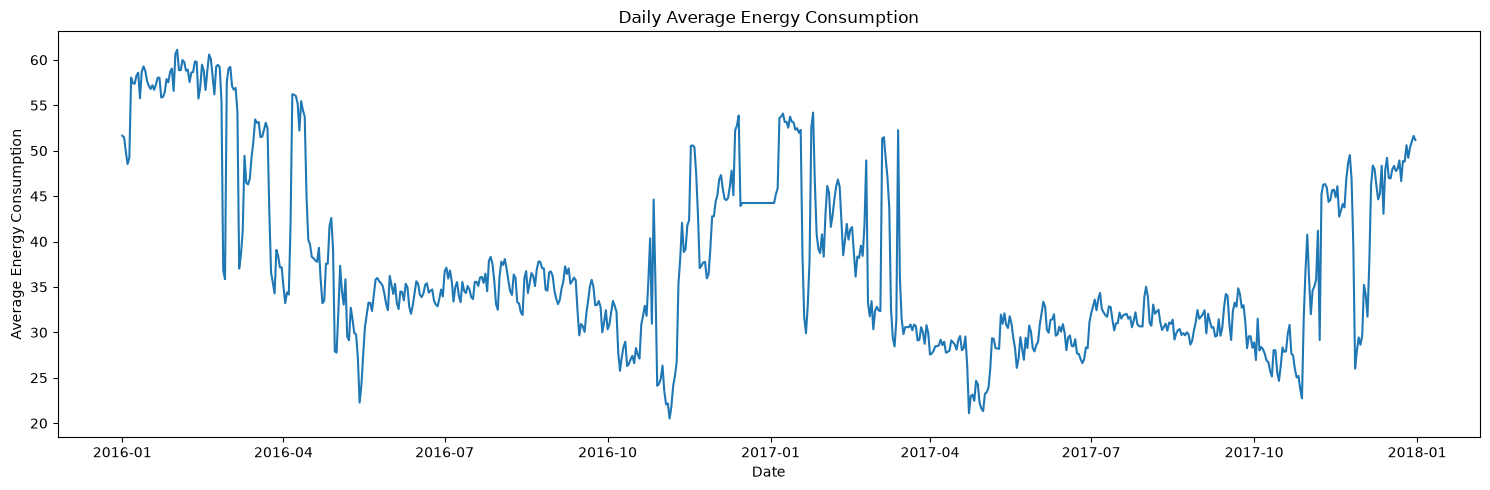

,year,month,energy_consumption,period
0,2016,1,56.468132,2016-01
1,2016,2,57.098967,2016-02
2,2016,3,47.462410,2016-03
3,2016,4,42.113749,2016-04
4,2016,5,32.059868,2016-05
5,2016,6,34.162671,2016-06
6,2016,7,35.328310,2016-07
7,2016,8,35.786173,2016-08
8,2016,9,33.659781,2016-09
9,2016,10,30.155509,2016-10


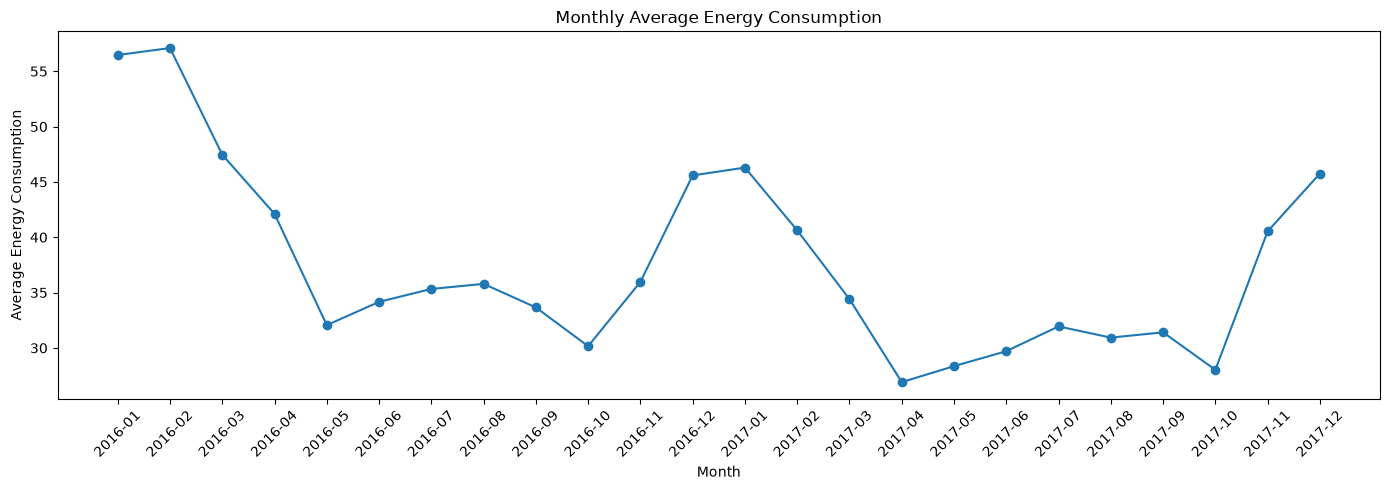

In [19]:
#Daily Consumption
daily_energy = (
    analysis_df
    .set_index("timestamp")["energy_consumption"]
    .resample("D")
    .mean()
)

plt.figure(figsize=(15, 5))

plt.plot(daily_energy.index, daily_energy.values)

plt.title("Daily Average Energy Consumption")
plt.xlabel("Date")
plt.ylabel("Average Energy Consumption")

plt.tight_layout()
plt.show()

#Monthly Consumption
monthly_energy = (
    analysis_df
    .groupby(["year", "month"])["energy_consumption"]
    .mean()
    .reset_index()
)

monthly_energy["period"] = (
    monthly_energy["year"].astype(str)
    + "-"
    + monthly_energy["month"].astype(str).str.zfill(2)
)

display(monthly_energy)
plt.figure(figsize=(14, 5))

plt.plot(
    monthly_energy["period"],
    monthly_energy["energy_consumption"],
    marker="o"
)

plt.title("Monthly Average Energy Consumption")
plt.xlabel("Month")
plt.ylabel("Average Energy Consumption")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [20]:
#Correlation Analysis
numeric_cols = [
    "energy_consumption",
    "airTemperature",
    "dewTemperature",
    "precipDepth1HR",
    "seaLvlPressure",
    "windDirection",
    "windSpeed",
    "hour",
    "day_of_week",
    "month",
    "is_weekend"
]

correlation = (
    analysis_df[numeric_cols]
    .corr()["energy_consumption"]
    .sort_values(ascending=False)
)

display(correlation)


energy_consumption    1.000000
seaLvlPressure        0.105482
windDirection         0.102480
hour                  0.080540
windSpeed             0.058282
day_of_week          -0.027965
precipDepth1HR       -0.036579
is_weekend           -0.046846
month                -0.229137
dewTemperature       -0.454378
airTemperature       -0.479766
Name: energy_consumption, dtype: float64

In [21]:
#Detect Potential energy anomalies
Q1 = analysis_df["energy_consumption"].quantile(0.25)
Q3 = analysis_df["energy_consumption"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

analysis_df["is_anomaly"] = (
    (analysis_df["energy_consumption"] < lower_bound) |
    (analysis_df["energy_consumption"] > upper_bound)
)

print("Lower bound:", round(lower_bound, 2))
print("Upper bound:", round(upper_bound, 2))
print("Potential anomalies:", analysis_df["is_anomaly"].sum())
print(
    "Anomaly percentage:",
    round(analysis_df["is_anomaly"].mean() * 100, 2),
    "%"
)
display(
    analysis_df[
        analysis_df["is_anomaly"]
    ][
        ["timestamp", "energy_consumption", "airTemperature"]
    ].head(20)
)

Lower bound: -2.03
Upper bound: 75.02
Potential anomalies: 2
Anomaly percentage: 0.01 %


,timestamp,energy_consumption,airTemperature
725,2016-01-31 05:00:00,76.700,0.0
2491,2016-04-13 19:00:00,75.889,17.8


In [22]:
#Create forecasting features
# Make sure data is sorted
analysis_df = analysis_df.sort_values("timestamp").reset_index(drop=True)

# Historical energy consumption
analysis_df["lag_1h"] = analysis_df["energy_consumption"].shift(1)
analysis_df["lag_2h"] = analysis_df["energy_consumption"].shift(2)
analysis_df["lag_24h"] = analysis_df["energy_consumption"].shift(24)
analysis_df["lag_168h"] = analysis_df["energy_consumption"].shift(168)

# Rolling averages
analysis_df["rolling_24h"] = (
    analysis_df["energy_consumption"]
    .shift(1)
    .rolling(24)
    .mean()
)

analysis_df["rolling_168h"] = (
    analysis_df["energy_consumption"]
    .shift(1)
    .rolling(168)
    .mean()
)

# Remove rows created by lagging
model_df = analysis_df.dropna().copy()

print("Original rows:", len(analysis_df))
print("Model rows:", len(model_df))

display(model_df.head())

#Select features and target
features = [
    "airTemperature",
    "dewTemperature",
    "precipDepth1HR",
    "seaLvlPressure",
    "windDirection",
    "windSpeed",
    "hour",
    "day_of_week",
    "month",
    "is_weekend",
    "lag_1h",
    "lag_2h",
    "lag_24h",
    "lag_168h",
    "rolling_24h",
    "rolling_168h"
]

target = "energy_consumption"

X = model_df[features]
y = model_df[target]

print("Features:", X.shape)
print("Target:", y.shape)

#Split data into training and testing sets
split_index = int(len(model_df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nTraining period:")
print(model_df["timestamp"].iloc[:split_index].min())
print("to")
print(model_df["timestamp"].iloc[split_index - 1])

print("\nTesting period:")
print(model_df["timestamp"].iloc[split_index])
print("to")
print(model_df["timestamp"].iloc[-1])

Original rows: 17544
Model rows: 17376


,timestamp,energy_consumption,site_id,airTemperature,dewTemperature,precipDepth1HR,seaLvlPressure,windDirection,windSpeed,hour,...,month,year,is_weekend,is_anomaly,lag_1h,lag_2h,lag_24h,lag_168h,rolling_24h,rolling_168h
168,2016-01-08 00:00:00,45.234,Hog,0.6,-0.6,8.0,1012.2,10.0,1.5,0,...,1,2016,0,False,46.538,47.330,45.932,43.321,57.419292,52.325589
169,2016-01-08 01:00:00,47.367,Hog,0.6,-0.6,5.0,1011.5,360.0,1.5,1,...,1,2016,0,False,45.234,46.538,48.085,43.321,57.390208,52.336976
170,2016-01-08 02:00:00,52.886,Hog,0.0,-0.6,5.0,1011.1,360.0,2.1,2,...,1,2016,0,False,47.367,45.234,55.049,43.287,57.360292,52.361060
171,2016-01-08 03:00:00,51.078,Hog,0.0,-0.6,3.0,1011.0,10.0,2.6,3,...,1,2016,0,False,52.886,47.367,52.957,41.966,57.270167,52.418196
172,2016-01-08 04:00:00,54.393,Hog,0.0,-0.6,3.0,1010.6,10.0,2.1,4,...,1,2016,0,False,51.078,52.886,53.857,47.349,57.191875,52.472435


Features: (17376, 16)
Target: (17376,)
Training samples: 13900
Testing samples: 3476

Training period:
2016-01-08 00:00:00
to
2017-08-09 03:00:00

Testing period:
2017-08-09 04:00:00
to
2017-12-31 23:00:00


✅ Random Forest model trained successfully!
Predictions generated: 3476


,Actual,Predicted
0,31.090,32.445349
1,43.643,42.346133
2,43.515,46.092801
3,38.019,37.359749
4,32.505,28.516717
5,31.113,29.585096
6,27.516,29.642982
7,27.125,27.534008
8,27.306,27.953639
9,27.021,28.086217


MODEL PERFORMANCE
MAE  : 2.2191
RMSE : 3.2675
R²   : 0.9149


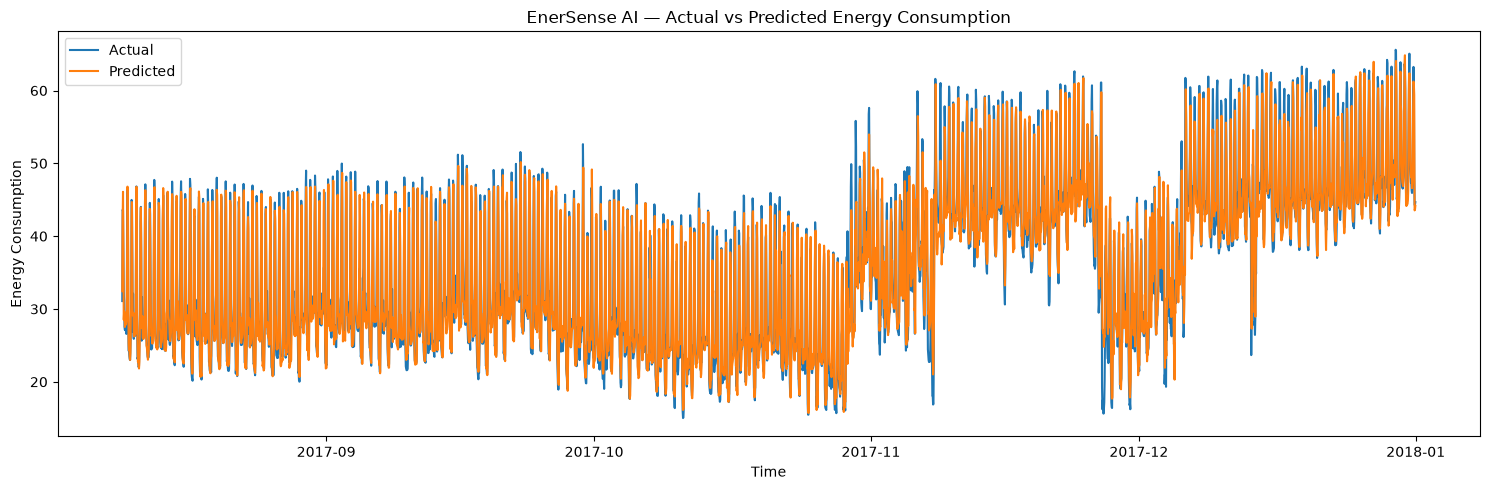

In [23]:
#Train the first EnerSense forecasting model
from sklearn.ensemble import RandomForestRegressor

# Create Random Forest model
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=20,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

# Train
rf_model.fit(X_train, y_train)

print("✅ Random Forest model trained successfully!")

#Make predictions and evaluate the model
# Predict on unseen test data
y_pred = rf_model.predict(X_test)

print("Predictions generated:", len(y_pred))

display(
    pd.DataFrame({
        "Actual": y_test.values[:10],
        "Predicted": y_pred[:10]
    })
)
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(
    mean_squared_error(y_test, y_pred)
)

r2 = r2_score(y_test, y_pred)

print("MODEL PERFORMANCE")
print("=" * 40)
print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")

#Actual vs Predicted
plt.figure(figsize=(15, 5))

plt.plot(
    model_df["timestamp"].iloc[split_index:],
    y_test.values,
    label="Actual"
)

plt.plot(
    model_df["timestamp"].iloc[split_index:],
    y_pred,
    label="Predicted"
)

plt.title("EnerSense AI — Actual vs Predicted Energy Consumption")
plt.xlabel("Time")
plt.ylabel("Energy Consumption")

plt.legend()
plt.tight_layout()
plt.show()


,feature,importance
12,lag_24h,0.662767
10,lag_1h,0.252241
14,rolling_24h,0.019245
11,lag_2h,0.012938
13,lag_168h,0.011916
6,hour,0.011035
15,rolling_168h,0.006678
0,airTemperature,0.004385
1,dewTemperature,0.004030
3,seaLvlPressure,0.003912


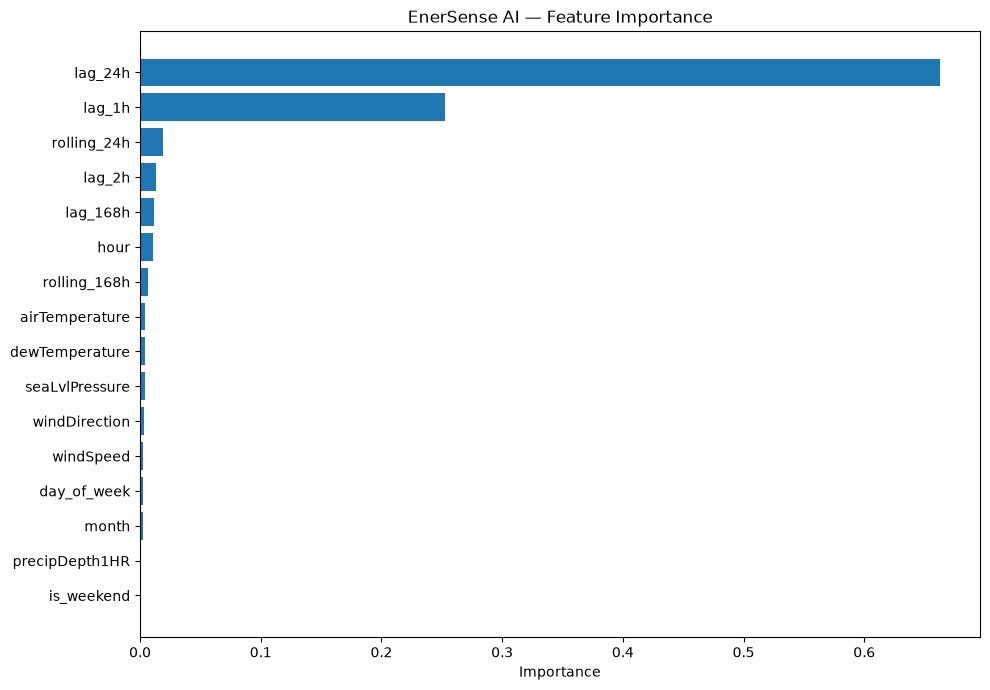

In [24]:
#Feature Importance
feature_importance = pd.DataFrame({
    "feature": features,
    "importance": rf_model.feature_importances_
}).sort_values(
    "importance",
    ascending=False
)

display(feature_importance)
plt.figure(figsize=(10, 7))

plt.barh(
    feature_importance["feature"],
    feature_importance["importance"]
)

plt.gca().invert_yaxis()

plt.title("EnerSense AI — Feature Importance")
plt.xlabel("Importance")

plt.tight_layout()
plt.show()



In [25]:
#Train Gradient Boosting model
from sklearn.ensemble import GradientBoostingRegressor

gb_model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    min_samples_leaf=3,
    random_state=42
)

gb_model.fit(X_train, y_train)

y_pred_gb = gb_model.predict(X_test)

mae_gb = mean_absolute_error(y_test, y_pred_gb)
rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))
r2_gb = r2_score(y_test, y_pred_gb)

print("GRADIENT BOOSTING PERFORMANCE")
print("=" * 40)
print(f"MAE  : {mae_gb:.4f}")
print(f"RMSE : {rmse_gb:.4f}")
print(f"R²   : {r2_gb:.4f}")

#Train HistGradientBoosting model
from sklearn.ensemble import HistGradientBoostingRegressor

hgb_model = HistGradientBoostingRegressor(
    max_iter=300,
    learning_rate=0.05,
    max_leaf_nodes=31,
    l2_regularization=0.1,
    random_state=42
)

hgb_model.fit(X_train, y_train)

y_pred_hgb = hgb_model.predict(X_test)

mae_hgb = mean_absolute_error(y_test, y_pred_hgb)
rmse_hgb = np.sqrt(mean_squared_error(y_test, y_pred_hgb))
r2_hgb = r2_score(y_test, y_pred_hgb)

print("HISTGRADIENT BOOSTING PERFORMANCE")
print("=" * 40)
print(f"MAE  : {mae_hgb:.4f}")
print(f"RMSE : {rmse_hgb:.4f}")
print(f"R²   : {r2_hgb:.4f}")

#Create model comparison 
model_comparison = pd.DataFrame({
    "Model": [
        "Random Forest",
        "Gradient Boosting",
        "HistGradientBoosting"
    ],
    "MAE": [
        mae,
        mae_gb,
        mae_hgb
    ],
    "RMSE": [
        rmse,
        rmse_gb,
        rmse_hgb
    ],
    "R2": [
        r2,
        r2_gb,
        r2_hgb
    ]
})

model_comparison = model_comparison.sort_values(
    "RMSE"
).reset_index(drop=True)

display(model_comparison)

GRADIENT BOOSTING PERFORMANCE
MAE  : 2.1311
RMSE : 3.1306
R²   : 0.9219
HISTGRADIENT BOOSTING PERFORMANCE
MAE  : 2.0751
RMSE : 3.0516
R²   : 0.9258


,Model,MAE,RMSE,R2
0,HistGradientBoosting,2.075091,3.051638,0.925760
1,Gradient Boosting,2.131087,3.130592,0.921869
2,Random Forest,2.219118,3.267513,0.914885


In [26]:
# Make HistGradientBoosting your production model
#Save the final model
import os
import joblib

# Create models directory
os.makedirs("../MODELS", exist_ok=True)

# Save model
model_path = "../MODELS/enerSense_histgradient_model.pkl"

joblib.dump(hgb_model, model_path)

print("✅ Model saved successfully!")
print("Location:", model_path)
print(os.path.exists(model_path))

#Save the feature list
features_path = "../MODELS/model_features.pkl"

joblib.dump(features, features_path)

print("✅ Feature list saved!")
print("Location:", features_path)

#Create a final model summary
final_model_summary = {
    "model": "HistGradientBoostingRegressor",
    "MAE": mae_hgb,
    "RMSE": rmse_hgb,
    "R2": r2_hgb,
    "training_samples": len(X_train),
    "testing_samples": len(X_test),
    "number_of_features": len(features)
}

final_model_summary

✅ Model saved successfully!
Location: ../MODELS/enerSense_histgradient_model.pkl
True
✅ Feature list saved!
Location: ../MODELS/model_features.pkl


{'model': 'HistGradientBoostingRegressor',
 'MAE': 2.0750914609402273,
 'RMSE': np.float64(3.051638077714183),
 'R2': 0.9257603789341987,
 'training_samples': 13900,
 'testing_samples': 3476,
 'number_of_features': 16}

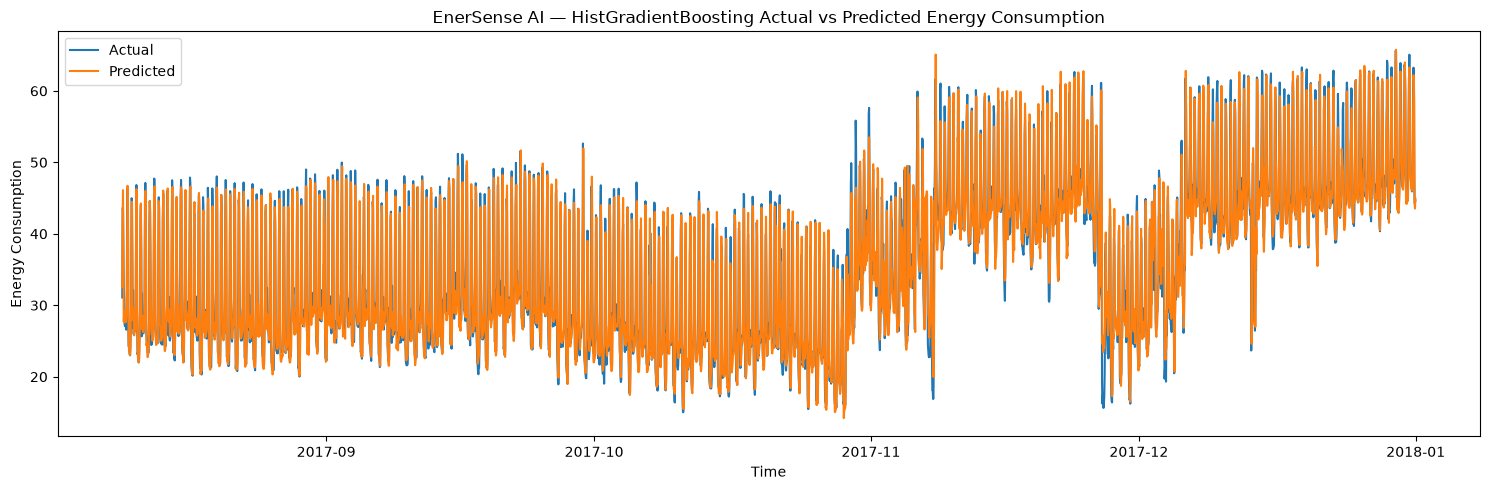

,timestamp,actual,predicted,error,absolute_error
0,2017-08-09 04:00:00,31.090,32.563258,-1.473258,1.473258
1,2017-08-09 05:00:00,43.643,42.636785,1.006215,1.006215
2,2017-08-09 06:00:00,43.515,46.109434,-2.594434,2.594434
3,2017-08-09 07:00:00,38.019,37.215835,0.803165,0.803165
4,2017-08-09 08:00:00,32.505,27.695765,4.809235,4.809235


Average absolute error: 2.0750914609402273
Maximum absolute error: 24.496407387580685


In [27]:
#Create final prediction visualization
plt.figure(figsize=(15, 5))

plt.plot(
    model_df["timestamp"].iloc[split_index:],
    y_test.values,
    label="Actual"
)

plt.plot(
    model_df["timestamp"].iloc[split_index:],
    y_pred_hgb,
    label="Predicted"
)

plt.title(
    "EnerSense AI — HistGradientBoosting "
    "Actual vs Predicted Energy Consumption"
)

plt.xlabel("Time")
plt.ylabel("Energy Consumption")

plt.legend()
plt.tight_layout()
plt.show()

#Calculate prediction errors
results = pd.DataFrame({
    "timestamp": model_df["timestamp"].iloc[split_index:].values,
    "actual": y_test.values,
    "predicted": y_pred_hgb
})

results["error"] = results["actual"] - results["predicted"]

results["absolute_error"] = results["error"].abs()

display(results.head())
print("Average absolute error:",
      results["absolute_error"].mean())

print("Maximum absolute error:",
      results["absolute_error"].max())

In [29]:
#Save the final predictions
# Create output directory
os.makedirs("../DATA/processed", exist_ok=True)

# Save predictions
results.to_csv(
    "../DATA/processed/energy_predictions.csv",
    index=False
)

print("✅ Prediction results saved!")
print(results.shape)
import os

print(
    os.path.exists(
        "../DATA/processed/energy_predictions.csv"
    )
)

#Save the final model
model_info = pd.DataFrame({
    "Model": ["HistGradientBoosting"],
    "MAE": [mae_hgb],
    "RMSE": [rmse_hgb],
    "R2": [r2_hgb],
    "Training_Samples": [len(X_train)],
    "Testing_Samples": [len(X_test)],
    "Features": [len(features)]
})

model_info.to_csv(
    "../DATA/processed/model_performance.csv",
    index=False
)

display(model_info)


✅ Prediction results saved!
(3476, 5)
True


,Model,MAE,RMSE,R2,Training_Samples,Testing_Samples,Features
0,HistGradientBoosting,2.075091,3.051638,0.92576,13900,3476,16
